# Klasifikasi Rimpang — COMPARE
Menggabungkan dan membandingkan hasil semua eksperimen.

> ⚠️ **Jalankan file ini terakhir**, setelah semua notebook eksperimen sudah dijalankan.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print('Import berhasil')

Import berhasil


### Import Library

Melakukan import beberapa library utama python yang dibutuhkan untuk analisis data dan visualisasi:
* `os`: Mengelola pengecekan direktori dan keberadaan file hasil eksprimen.
* `pandas (pd)`: Membaca, menggabungkan, dan memanipulasi data tabular dari file CSV.
* `matplotlib.pyplot (plt)` & `seaborn (sns)`: Membuat visualisasi grafik guna mempermudah perbandingan performa antar model dan skenario.

In [ ]:
EXP_NAMES = ['Baseline', 'P1_Grayscale', 'P2_CLAHE', 'P3_Blur_CLAHE', 'P4_Median_CLAHE']

all_results = []
for exp in EXP_NAMES:
    path = f'output/hasil_{exp}.csv'
    if os.path.exists(path):
        all_results.append(pd.read_csv(path))
        print(f'[OK] {path}')
    else:
        print(f'[MISSING] {path}')

df_all = pd.concat(all_results, ignore_index=True)
df_all.to_csv('output/hasil_perbandingan_semua.csv', index=False)
print(f'\nTotal: {len(df_all)} baris')
print(df_all.to_string(index=False))

[OK] output/hasil_Baseline.csv
[OK] output/hasil_P1_Grayscale.csv
[OK] output/hasil_P2_CLAHE.csv
[OK] output/hasil_P3_Blur_CLAHE.csv
[OK] output/hasil_P4_Median_CLAHE.csv

Total: 15 baris
     Eksperimen Model  Akurasi  Train_Akurasi
       Baseline   KNN    61.11          73.61
       Baseline   SVM    76.98          94.05
       Baseline    RF    73.02          99.01
   P1_Grayscale   KNN    64.29          74.21
   P1_Grayscale   SVM    76.98          92.06
   P1_Grayscale    RF    67.46          98.41
       P2_CLAHE   KNN    61.11          75.00
       P2_CLAHE   SVM    76.19          92.66
       P2_CLAHE    RF    70.63          98.21
  P3_Blur_CLAHE   KNN    57.14          73.41
  P3_Blur_CLAHE   SVM    74.60          88.69
  P3_Blur_CLAHE    RF    71.43          98.61
P4_Median_CLAHE   KNN    57.14          73.41
P4_Median_CLAHE   SVM    75.40          89.29
P4_Median_CLAHE    RF    72.22          98.21


### Analisis Perbandingan Metode Preprocessing

Penelitian ini membandingkan lima skenario preprocessing, yaitu **Baseline**, **P1 Grayscale**, **P2 CLAHE**, **P3 Gaussian Blur + CLAHE**, dan **P4 Median Blur + CLAHE**, menggunakan tiga algoritma klasifikasi yaitu KNN, SVM, dan Random Forest. Hasil pengujian menunjukkan bahwa pengaruh preprocessing terhadap performa klasifikasi tidak selalu positif dan sangat bergantung pada karakteristik fitur tekstur yang diekstraksi menggunakan GLCM.

### Analisis Berdasarkan Akurasi

| Eksperimen | KNN (%) | SVM (%) | RF (%) |
|------------|----------|----------|----------|
| Baseline | 61.11 | **76.98** | **73.02** |
| P1_Grayscale | **64.29** | **76.98** | 67.46 |
| P2_CLAHE | 61.11 | 76.19 | 70.63 |
| P3_Blur_CLAHE | 57.14 | 74.60 | 71.43 |
| P4_Median_CLAHE | 57.14 | 75.40 | 72.22 |

Secara keseluruhan, akurasi tertinggi diperoleh oleh model **SVM** pada skenario **Baseline** dan **P1 Grayscale**, yaitu sebesar **76.98%**. Hasil ini menunjukkan bahwa informasi tekstur pada citra rimpang sudah cukup representatif tanpa memerlukan peningkatan kontras atau proses peredaman noise yang kompleks. Dengan kata lain, fitur GLCM yang diekstraksi dari citra grayscale sederhana sudah mampu menangkap karakteristik tekstur yang membedakan antar kelas rimpang.

### Pengaruh Preprocessing Grayscale (P1)

Konversi citra ke grayscale memberikan peningkatan performa pada model KNN dari **61.11%** menjadi **64.29%**, sementara performa SVM tetap berada pada nilai tertinggi yaitu **76.98%**. Namun demikian, Random Forest mengalami penurunan akurasi dari **73.02%** menjadi **67.46%**.

Hasil tersebut menunjukkan bahwa informasi warna tidak memberikan kontribusi yang signifikan terhadap proses ekstraksi fitur GLCM karena metode ini berfokus pada hubungan spasial antar tingkat keabuan. Oleh karena itu, penggunaan grayscale mampu menyederhanakan representasi citra tanpa menghilangkan informasi tekstur yang penting.

### Pengaruh CLAHE (P2)

CLAHE diterapkan untuk meningkatkan kontras lokal sehingga detail tekstur menjadi lebih jelas. Namun hasil pengujian menunjukkan bahwa peningkatan kontras tersebut tidak menghasilkan peningkatan akurasi yang signifikan.

| Model | Baseline (%) | P2 CLAHE (%) |
|---------|---------|---------|
| KNN | 61.11 | 61.11 |
| SVM | 76.98 | 76.19 |
| RF | 73.02 | 70.63 |

Penurunan kecil pada seluruh model mengindikasikan bahwa tekstur rimpang dalam dataset telah memiliki kontras yang cukup baik. Akibatnya, peningkatan kontras menggunakan CLAHE justru dapat mengubah distribusi tekstur asli yang digunakan dalam perhitungan fitur GLCM sehingga tidak memberikan keuntungan terhadap proses klasifikasi.

### Pengaruh Gaussian Blur + CLAHE (P3)

Penerapan Gaussian Blur sebelum CLAHE menghasilkan penurunan performa pada seluruh model.

| Model | Baseline (%) | P3 Blur + CLAHE (%) |
|---------|---------|---------|
| KNN | 61.11 | 57.14 |
| SVM | 76.98 | 74.60 |
| RF | 73.02 | 71.43 |

Penurunan ini dapat dijelaskan karena Gaussian Blur bekerja dengan menghaluskan citra dan mengurangi variasi intensitas lokal. Sementara itu, fitur GLCM sangat bergantung pada pola hubungan antar piksel yang membentuk tekstur. Ketika citra terlalu halus, sebagian informasi tekstur yang menjadi pembeda antar kelas akan hilang sehingga performa klasifikasi menurun.

### Pengaruh Median Blur + CLAHE (P4)

Median Blur menghasilkan performa yang sedikit lebih baik dibandingkan Gaussian Blur.

| Model | P3 Blur + CLAHE (%) | P4 Median + CLAHE (%) |
|---------|---------|---------|
| KNN | 57.14 | 57.14 |
| SVM | 74.60 | 75.40 |
| RF | 71.43 | 72.22 |

Median Blur mampu mengurangi noise tanpa menghilangkan tepi objek secara berlebihan. Oleh karena itu, informasi tekstur yang digunakan oleh GLCM dapat dipertahankan lebih baik dibandingkan Gaussian Blur. Meskipun demikian, peningkatan yang diperoleh masih belum mampu melampaui performa Baseline maupun Grayscale.

---

## Analisis Overfitting

### Random Forest

| Eksperimen | Test (%) | Train (%) |
|------------|----------|-----------|
| Baseline | 73.02 | 99.01 |
| P1_Grayscale | 67.46 | 98.41 |
| P2_CLAHE | 70.63 | 98.21 |
| P3_Blur_CLAHE | 71.43 | 98.61 |
| P4_Median_CLAHE | 72.22 | 98.21 |

Nilai akurasi pelatihan yang mendekati **100%** menunjukkan bahwa Random Forest memiliki kecenderungan **overfitting**, yaitu model mampu menghafal data latih dengan sangat baik tetapi kemampuan generalisasinya terhadap data uji lebih rendah. Selisih akurasi train-test yang cukup besar pada seluruh eksperimen mendukung indikasi tersebut.

### Support Vector Machine (SVM)

| Eksperimen | Test (%) | Train (%) |
|------------|----------|-----------|
| Baseline | 76.98 | 94.05 |
| P1_Grayscale | 76.98 | 92.06 |
| P2_CLAHE | 76.19 | 92.66 |
| P3_Blur_CLAHE | 74.60 | 88.69 |
| P4_Median_CLAHE | 75.40 | 89.29 |

Dibandingkan Random Forest, SVM memiliki selisih akurasi train-test yang lebih kecil. Hal ini menunjukkan bahwa SVM memiliki kemampuan generalisasi yang lebih baik sehingga mampu mempertahankan performa ketika diuji pada data yang belum pernah dilihat sebelumnya.

---

## Kesimpulan

Berdasarkan hasil pengujian, dapat disimpulkan bahwa preprocessing yang lebih kompleks tidak selalu menghasilkan peningkatan performa klasifikasi. Metode **P1 Grayscale** memberikan hasil yang paling konsisten karena mampu mempertahankan informasi tekstur penting sambil menyederhanakan representasi citra. Sebaliknya, penerapan CLAHE maupun kombinasi blur dan CLAHE cenderung tidak memberikan peningkatan performa yang signifikan, bahkan pada beberapa kasus menyebabkan penurunan akurasi karena mengubah pola tekstur yang menjadi dasar ekstraksi fitur GLCM.

Model terbaik pada penelitian ini adalah **Support Vector Machine (SVM)** dengan preprocessing **Grayscale (P1)** yang memperoleh akurasi sebesar **76.98%**. Selain menghasilkan akurasi tertinggi, SVM juga menunjukkan kemampuan generalisasi yang lebih baik dibandingkan Random Forest berdasarkan selisih akurasi training dan testing yang lebih kecil. Oleh karena itu, kombinasi **Grayscale → Ekstraksi Fitur GLCM → SVM** dapat dianggap sebagai konfigurasi yang paling efektif untuk klasifikasi jenis rimpang pada dataset yang digunakan dalam penelitian ini.

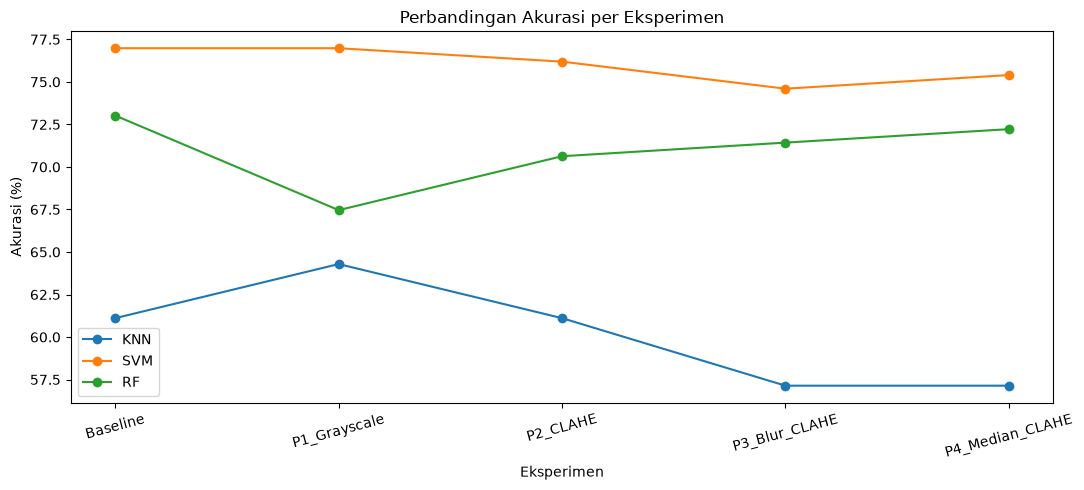

Disimpan ke output/grafik_perbandingan.png


In [3]:
# Cell 3 — Grafik line perbandingan
plt.figure(figsize=(11, 5))
for model_name in ['KNN', 'SVM', 'RF']:
    subset = df_all[df_all['Model'] == model_name]
    plt.plot(subset['Eksperimen'], subset['Akurasi'], marker='o', label=model_name)

plt.title('Perbandingan Akurasi per Eksperimen')
plt.ylabel('Akurasi (%)')
plt.xlabel('Eksperimen')
plt.legend()
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('output/grafik_perbandingan.png', dpi=150)
plt.show()
print('Disimpan ke output/grafik_perbandingan.png')

### Analisis Grafik Perbandingan Akurasi per Eksperimen

Grafik menunjukkan perbandingan akurasi tiga algoritma klasifikasi, yaitu **K-Nearest Neighbor (KNN)**, **Support Vector Machine (SVM)**, dan **Random Forest (RF)** pada lima skenario preprocessing yang berbeda. Secara umum, terlihat bahwa performa setiap algoritma memberikan respons yang berbeda terhadap perubahan metode preprocessing yang diterapkan.

### Performa KNN

Kurva KNN menunjukkan fluktuasi yang cukup besar dibandingkan model lainnya. Akurasi meningkat dari **61.11%** pada Baseline menjadi **64.29%** pada P1 Grayscale, yang merupakan nilai tertinggi untuk KNN. Namun setelah penerapan CLAHE dan kombinasi blur, performanya terus menurun hingga mencapai **57.14%** pada P3 Blur + CLAHE dan P4 Median + CLAHE.

Penurunan ini mengindikasikan bahwa KNN sangat sensitif terhadap perubahan distribusi fitur yang dihasilkan oleh preprocessing. Karena KNN melakukan klasifikasi berdasarkan jarak antar sampel, perubahan tekstur akibat peningkatan kontras atau proses smoothing dapat menyebabkan jarak antar kelas menjadi kurang terpisah dengan baik.

### Performa SVM

SVM secara konsisten menjadi model dengan akurasi tertinggi pada seluruh eksperimen. Akurasi tertinggi sebesar **76.98%** diperoleh pada Baseline dan P1 Grayscale. Setelah penerapan CLAHE dan filtering, terjadi penurunan kecil hingga mencapai **74.60%** pada P3 Blur + CLAHE sebelum kembali meningkat menjadi **75.40%** pada P4 Median + CLAHE.

Stabilitas kurva SVM menunjukkan bahwa model ini memiliki kemampuan generalisasi yang baik terhadap perubahan karakteristik fitur tekstur. Meskipun terdapat sedikit penurunan setelah preprocessing yang lebih kompleks, selisih akurasi yang relatif kecil menunjukkan bahwa SVM tetap mampu mempertahankan performa klasifikasi secara konsisten.

### Performa Random Forest

Random Forest menunjukkan pola yang berbeda dibandingkan KNN dan SVM. Akurasi awal pada Baseline mencapai **73.02%**, kemudian mengalami penurunan cukup signifikan menjadi **67.46%** pada P1 Grayscale. Namun setelah penerapan CLAHE dan kombinasi blur, performanya meningkat secara bertahap hingga mencapai **72.22%** pada P4 Median + CLAHE.

Pola ini menunjukkan bahwa Random Forest memperoleh manfaat dari peningkatan kontras dan reduksi noise yang dilakukan pada preprocessing lanjutan. Meskipun demikian, peningkatan tersebut belum mampu melampaui performa Baseline sehingga keuntungan yang diperoleh relatif terbatas.

### Perbandingan Antar Metode Preprocessing

Berdasarkan grafik, dapat diamati bahwa:

- **P1 Grayscale** memberikan hasil terbaik untuk KNN dan mempertahankan performa tertinggi pada SVM.
- **P2 CLAHE** tidak memberikan peningkatan akurasi yang signifikan pada seluruh model.
- **P3 Blur + CLAHE** menghasilkan performa terendah pada hampir semua model karena proses smoothing mengurangi detail tekstur yang diperlukan oleh GLCM.
- **P4 Median + CLAHE** menunjukkan perbaikan dibandingkan P3, terutama pada SVM dan Random Forest, karena Median Blur lebih mampu mempertahankan struktur tepi dibandingkan Gaussian Blur.
- Tidak terdapat metode preprocessing yang mampu mengungguli performa SVM pada Baseline maupun Grayscale.

### Kesimpulan

Grafik menunjukkan bahwa penggunaan preprocessing yang lebih kompleks tidak selalu menghasilkan peningkatan performa klasifikasi. Untuk dataset rimpang yang digunakan, informasi tekstur asli ternyata sudah cukup representatif sehingga preprocessing sederhana berupa **grayscale** mampu memberikan hasil yang setara bahkan lebih baik dibandingkan kombinasi CLAHE dan filtering. Selain itu, **SVM merupakan model yang paling stabil dan konsisten**, dengan akurasi tertinggi sebesar **76.98%**, sehingga kombinasi **Grayscale → Ekstraksi Fitur GLCM → SVM** dapat dianggap sebagai konfigurasi terbaik berdasarkan hasil eksperimen yang diperoleh.

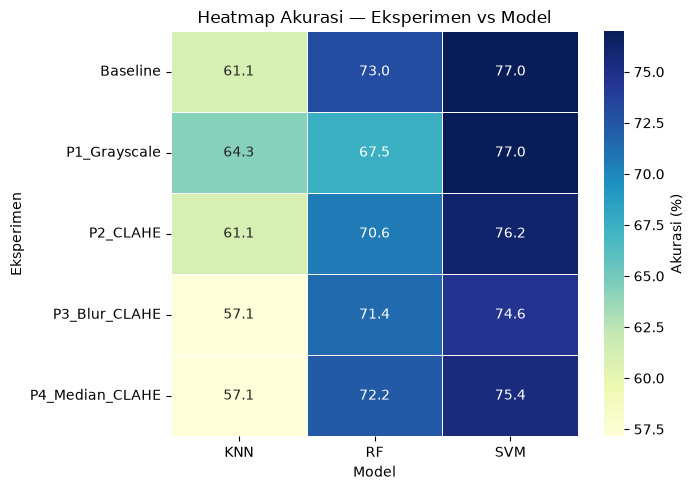

Disimpan ke output/heatmap_perbandingan.png


In [6]:
# Cell 4 — Heatmap akurasi
pivot = df_all.pivot(index='Eksperimen', columns='Model', values='Akurasi').reindex(EXP_NAMES)

plt.figure(figsize=(7, 5))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlGnBu',
            linewidths=0.5, cbar_kws={'label': 'Akurasi (%)'})
plt.title('Heatmap Akurasi — Eksperimen vs Model')
plt.tight_layout()
plt.savefig('output/heatmap_perbandingan.png', dpi=150)
plt.show()
print('Disimpan ke output/heatmap_perbandingan.png')

### Analisis Heatmap Akurasi Eksperimen vs Model

Heatmap di atas menunjukkan perbandingan akurasi tiga model klasifikasi, yaitu **KNN**, **Random Forest (RF)**, dan **SVM**, pada lima skenario preprocessing yang berbeda, yaitu **Baseline**, **P1_Grayscale**, **P2_CLAHE**, **P3_Blur_CLAHE**, dan **P4_Median_CLAHE**. Secara umum, terlihat bahwa **SVM memberikan performa terbaik pada hampir semua eksperimen**, sedangkan **KNN memiliki akurasi terendah** di seluruh skenario.

Pada **Baseline**, SVM memperoleh akurasi tertinggi sebesar **77.0%**, diikuti RF sebesar **73.0%**, dan KNN sebesar **61.1%**. Hasil ini menunjukkan bahwa tanpa preprocessing tambahan pun, fitur tekstur yang diekstraksi sudah cukup representatif untuk diklasifikasikan oleh SVM. Pada **P1_Grayscale**, akurasi KNN meningkat menjadi **64.3%**, tetapi RF justru turun menjadi **67.5%**, sementara SVM tetap stabil di **77.0%**. Hal ini mengindikasikan bahwa konversi ke grayscale dapat membantu model sederhana seperti KNN, tetapi tidak memberikan peningkatan berarti pada model yang lebih kuat.

Pada **P2_CLAHE**, akurasi KNN kembali turun ke **61.1%**, RF naik sedikit menjadi **70.6%**, dan SVM menurun tipis ke **76.2%**. Artinya, CLAHE tidak memberikan keuntungan signifikan terhadap klasifikasi tekstur rimpang, meskipun pada RF masih terlihat sedikit perbaikan. Sementara itu, pada **P3_Blur_CLAHE** dan **P4_Median_CLAHE**, akurasi KNN menjadi yang terendah, yaitu **57.1%**, yang menunjukkan bahwa proses blur justru mengurangi detail tekstur penting. RF dan SVM masih bertahan cukup baik, dengan RF mencapai **71.4%–72.2%** dan SVM berada pada rentang **74.6%–75.4%**.

Dari heatmap ini dapat disimpulkan bahwa:

- **SVM merupakan model paling stabil dan paling akurat** pada seluruh skenario preprocessing.
- **KNN paling sensitif terhadap perubahan preprocessing**, terutama ketika detail tekstur mulai berkurang akibat blur.
- **Random Forest berada di posisi tengah**, dengan performa yang cukup konsisten tetapi masih di bawah SVM.
- **Preprocessing yang lebih kompleks tidak selalu meningkatkan akurasi**, karena pada beberapa kasus justru mengurangi informasi tekstur yang dibutuhkan oleh fitur GLCM.

Secara keseluruhan, heatmap ini memperkuat temuan bahwa **kombinasi fitur tekstur sederhana dengan SVM** memberikan hasil terbaik untuk klasifikasi rimpang pada dataset ini.  

In [ ]:
# Cell 5 — Ringkasan
best = df_all.loc[df_all['Akurasi'].idxmax()]
print('=== HASIL TERBAIK ===')
print(f'Eksperimen : {best["Eksperimen"]}')
print(f'Model      : {best["Model"]}')
print(f'Akurasi    : {best["Akurasi"]}%')

print('\n=== RATA-RATA PER EKSPERIMEN ===')
print(df_all.groupby('Eksperimen')['Akurasi'].mean().reindex(EXP_NAMES).round(2).to_string())

print('\n=== RATA-RATA PER MODEL ===')
print(df_all.groupby('Model')['Akurasi'].mean().round(2).to_string())

=== HASIL TERBAIK ===
Eksperimen : Baseline
Model      : SVM
Akurasi    : 76.98%

=== RATA-RATA PER EKSPERIMEN ===
Eksperimen
Baseline           70.37
P1_Grayscale       69.58
P2_CLAHE           69.31
P3_Blur_CLAHE      67.72
P4_Median_CLAHE    68.25

=== RATA-RATA PER MODEL ===
Model
KNN    60.16
RF     70.95
SVM    76.03


### Analisis Hasil Terbaik dan Rata-Rata Performa

Berdasarkan hasil pengujian, **model terbaik** yang diperoleh adalah **SVM pada eksperimen Baseline** dengan akurasi sebesar **76.98%**. Hasil ini menunjukkan bahwa kombinasi fitur tekstur asli tanpa preprocessing tambahan justru mampu memberikan performa klasifikasi paling optimal. Dengan demikian, untuk dataset rimpang yang digunakan, informasi tekstur dasar sudah cukup representatif sehingga proses preprocessing lanjutan tidak memberikan peningkatan yang berarti.

### Analisis Rata-Rata per Eksperimen

| Eksperimen | Rata-rata Akurasi (%) |
|------------|-----------------------|
| Baseline | 70.37 |
| P1_Grayscale | 69.58 |
| P2_CLAHE | 69.31 |
| P3_Blur_CLAHE | 67.72 |
| P4_Median_CLAHE | 68.25 |

Dari tabel di atas, **Baseline** memiliki rata-rata akurasi tertinggi yaitu **70.37%**, sedangkan **P3_Blur_CLAHE** memiliki rata-rata terendah yaitu **67.72%**. Hal ini menunjukkan bahwa preprocessing yang lebih kompleks tidak selalu menghasilkan peningkatan performa. Bahkan, beberapa metode seperti blur dapat mengurangi detail tekstur yang justru dibutuhkan oleh ekstraksi fitur GLCM.

Urutan rata-rata performa per eksperimen memperlihatkan bahwa:
1. **Baseline** memberikan hasil terbaik secara umum.
2. **Grayscale** masih mempertahankan performa yang relatif baik.
3. **CLAHE** tidak mampu meningkatkan akurasi secara signifikan.
4. **Blur + CLAHE** cenderung menurunkan performa karena menghilangkan detail tekstur.
5. **Median + CLAHE** sedikit lebih baik daripada Gaussian Blur + CLAHE, tetapi tetap belum melampaui baseline.

### Analisis Rata-Rata per Model

| Model | Rata-rata Akurasi (%) |
|-------|------------------------|
| KNN | 60.16 |
| RF | 70.95 |
| SVM | 76.03 |

Berdasarkan rata-rata per model, **SVM** menjadi algoritma dengan performa terbaik, yaitu **76.03%**, diikuti oleh **Random Forest** sebesar **70.95%**, sedangkan **KNN** memiliki performa terendah yaitu **60.16%**. Hasil ini menunjukkan bahwa SVM lebih mampu menangkap pola pemisahan antar kelas pada fitur GLCM dibandingkan KNN dan Random Forest.

Kinerja KNN yang rendah mengindikasikan bahwa metode berbasis jarak ini kurang cocok untuk distribusi fitur tekstur yang kompleks dan mungkin saling tumpang tindih. Random Forest menunjukkan performa yang cukup baik, tetapi masih belum sebaik SVM. Sementara itu, SVM lebih stabil karena mampu membentuk batas keputusan yang lebih efektif pada ruang fitur tekstur.

### Kesimpulan

Secara keseluruhan, hasil eksperimen menunjukkan bahwa **SVM merupakan model terbaik** untuk klasifikasi rimpang berbasis fitur GLCM pada dataset ini. Sementara itu, **preprocessing Baseline** justru memberikan hasil rata-rata tertinggi dibandingkan metode preprocessing lainnya. Dengan demikian, pipeline yang paling efektif dalam penelitian ini adalah **citra asli atau grayscale sederhana → ekstraksi fitur GLCM → klasifikasi menggunakan SVM**.

Hasil ini juga menegaskan bahwa pada kasus klasifikasi tekstur rimpang, preprocessing yang terlalu agresif seperti blur dan CLAHE tidak selalu diperlukan karena dapat mengubah karakteristik tekstur asli yang penting bagi proses klasifikasi.